<a href="https://colab.research.google.com/github/Sanath-cmd/Internship_ITT/blob/main/Algorithms/CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
transform = transforms.ToTensor()

In [3]:
train_data = datasets.MNIST(root = 'cnn data', train = True, download= True, transform = transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.22MB/s]


In [4]:
test_data= datasets.MNIST(root = 'cnn data', train = False, download= True, transform = transform)

In [5]:
train_loader = DataLoader(train_data, batch_size = 10, shuffle= True)
test_loader = DataLoader(test_data, batch_size= 10, shuffle= False)

In [6]:
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [7]:
class ConvolutionNetwork(nn.Module):

  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 3, 1)
    self.conv2 = nn.Conv2d(6, 16, 3, 1)
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X, 2, 2)
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X, 2, 2)
    X = X.view(-1, 16*5*5)
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)
    return F.log_softmax(X, dim = 1)

In [8]:
torch.manual_seed(42)
model= ConvolutionNetwork()
model

ConvolutionNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [10]:
import time
start = time.time()
epochs = 5
train_losses= []
test_losses= []
train_correct= []
test_correct= []
for i in range(epochs):
  trn_corr= 0
  tst_corr= 0
  for b, (X_train, y_train) in enumerate (train_loader):
    b+= 1
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    predicted = torch.max(y_pred.data, 1)[1]
    batch_corr = (predicted== y_train).sum()
    trn_corr+= batch_corr

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if b%600 == 0:
      print(f'Epoch: {i}, Batch: {b}, Loss: {loss.item()}')
  train_losses.append(loss)
  train_correct.append(trn_corr)

  with torch.no_grad():#test
   for b, (X_test, y_test) in enumerate (test_loader):
    y_val = model(X_test)
    predicted = torch.max(y_val.data, 1)[1]
    tst_corr+= (predicted == y_test).sum()

  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)




current_time = time.time()
total_time = current_time - start
print(f'This took {total_time/60} minutes!')

Epoch: 0, Batch: 600, Loss: 0.040556274354457855
Epoch: 0, Batch: 1200, Loss: 0.08253474533557892
Epoch: 0, Batch: 1800, Loss: 0.3647049069404602
Epoch: 0, Batch: 2400, Loss: 0.018250251188874245
Epoch: 0, Batch: 3000, Loss: 0.008067040704190731
Epoch: 0, Batch: 3600, Loss: 0.001166942878626287
Epoch: 0, Batch: 4200, Loss: 0.5255253911018372
Epoch: 0, Batch: 4800, Loss: 0.03260819613933563
Epoch: 0, Batch: 5400, Loss: 0.007468158844858408
Epoch: 0, Batch: 6000, Loss: 0.03889675810933113
Epoch: 1, Batch: 600, Loss: 0.032828204333782196
Epoch: 1, Batch: 1200, Loss: 0.04554177075624466
Epoch: 1, Batch: 1800, Loss: 0.005784796085208654
Epoch: 1, Batch: 2400, Loss: 0.02235613949596882
Epoch: 1, Batch: 3000, Loss: 0.21643038094043732
Epoch: 1, Batch: 3600, Loss: 0.00501451687887311
Epoch: 1, Batch: 4200, Loss: 0.00045869071618653834
Epoch: 1, Batch: 4800, Loss: 0.0019295118981972337
Epoch: 1, Batch: 5400, Loss: 0.0008596166153438389
Epoch: 1, Batch: 6000, Loss: 0.08304359018802643
Epoch: 2, 

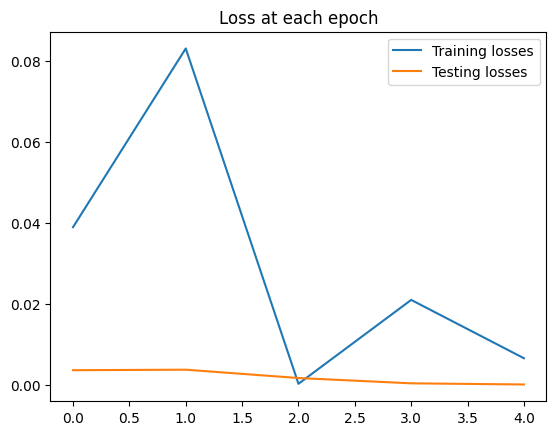

In [11]:
plt.plot([loss.detach().numpy() for loss in train_losses], label= 'Training losses')
plt.plot([loss.detach().numpy() for loss in test_losses], label= 'Testing losses')
plt.title('Loss at each epoch')
plt.legend()
plt.show()

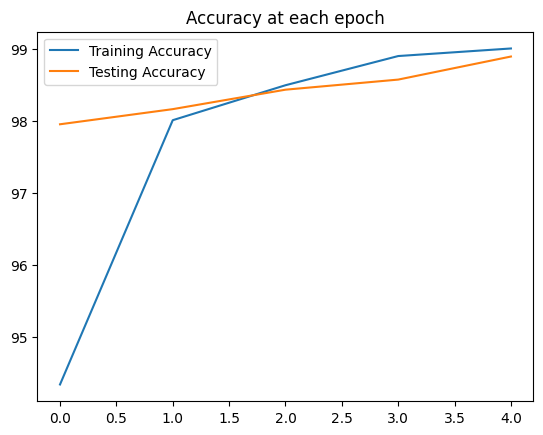

In [12]:
plt.plot([t/600 for t in train_correct], label= 'Training Accuracy')
plt.plot([t/100 for t in test_correct], label= 'Testing Accuracy')
plt.title('Accuracy at each epoch')
plt.legend()
plt.show()

In [5]:
torch.cuda.device_count()

1

In [6]:
if torch.cuda.is_available():
    print(f"CUDA Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available.")

CUDA Device Name: Tesla T4
